In [4]:
###############################################################
# 1) Настройка подключения к PostgreSQL через psycopg2
###############################################################
import os
import psycopg2
import numpy as np
import pandas as pd
from scipy.optimize import linprog
import matplotlib.pyplot as plt

try:
    from caas_jupyter_tools import display_dataframe_to_user
except:

    def display_dataframe_to_user(name, df):
        print("\n---", name, "---")
        display(df)


DB_HOST = "localhost"
DB_PORT = 1488
DB_NAME = "dissertation"
DB_USER = "postgres"
DB_PASS = "pass"

conn = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, dbname=DB_NAME, user=DB_USER, password=DB_PASS
)
conn.autocommit = True
cur = conn.cursor()

In [5]:
###############################################################
# 2) Полное создание схемы (аналогично SQLite-версии)
###############################################################
cur.execute("""
DROP TABLE IF EXISTS desirability_functions CASCADE;
DROP TABLE IF EXISTS plan_values CASCADE;
DROP TABLE IF EXISTS external_production_plans CASCADE;
DROP TABLE IF EXISTS production_chains CASCADE;
DROP TABLE IF EXISTS products CASCADE;
DROP TABLE IF EXISTS producers CASCADE;
DROP TABLE IF EXISTS abstract_products CASCADE;

CREATE TABLE abstract_products (
  id SERIAL PRIMARY KEY,
  name TEXT UNIQUE NOT NULL
);

CREATE TABLE producers (
  id SERIAL PRIMARY KEY,
  code TEXT UNIQUE NOT NULL
);

CREATE TABLE products (
  id SERIAL PRIMARY KEY,
  production_id INTEGER REFERENCES abstract_products(id),
  producer_id INTEGER REFERENCES producers(id),
  code TEXT NOT NULL
);

CREATE TABLE production_chains (
  id SERIAL PRIMARY KEY,
  input_product_id INTEGER REFERENCES products(id),
  output_product_id INTEGER REFERENCES products(id),
  amount NUMERIC NOT NULL
);

CREATE TABLE external_production_plans (
  id SERIAL PRIMARY KEY,
  name TEXT NOT NULL
);

CREATE TABLE plan_values (
  id SERIAL PRIMARY KEY,
  product_id INTEGER REFERENCES products(id),
  plan_id INTEGER REFERENCES external_production_plans(id),
  value NUMERIC NOT NULL
);

CREATE TABLE desirability_functions (
  product_id INTEGER PRIMARY KEY REFERENCES products(id),
  L NUMERIC NOT NULL,
  T NUMERIC NOT NULL,
  U NUMERIC NOT NULL
);
""")
print("БД структуру создана")

###############################################################
# 3) Наполнение данными
###############################################################
producers = [("P1",), ("P2",), ("P3",)]
cur.executemany("INSERT INTO producers(code) VALUES (%s)", producers)

abstracts = [("WidgetA",), ("WidgetB",), ("WidgetC",), ("WidgetD",)]
cur.executemany("INSERT INTO abstract_products(name) VALUES (%s)", abstracts)

cur.execute("SELECT id,code FROM producers")
producer_map = {code: pid for pid, code in cur.fetchall()}

cur.execute("SELECT id FROM abstract_products WHERE name='WidgetA'")
idA = cur.fetchone()[0]
cur.execute("SELECT id FROM abstract_products WHERE name='WidgetB'")
idB = cur.fetchone()[0]
cur.execute("SELECT id FROM abstract_products WHERE name='WidgetC'")
idC = cur.fetchone()[0]
cur.execute("SELECT id FROM abstract_products WHERE name='WidgetD'")
idD = cur.fetchone()[0]

products = [
    (idA, producer_map["P1"], "A_P1"),
    (idA, producer_map["P2"], "A_P2"),
    (idB, producer_map["P1"], "B_P1"),
    (idB, producer_map["P3"], "B_P3"),
    (idC, producer_map["P2"], "C_P2"),
    (idD, producer_map["P3"], "D_P3"),
]
cur.executemany(
    "INSERT INTO products(production_id,producer_id,code) VALUES(%s,%s,%s)", products
)

cur.execute("SELECT id,code FROM products")
prod_map = {code: pid for pid, code in cur.fetchall()}

chains = [
    (prod_map["A_P1"], prod_map["B_P1"], 0.2),
    (prod_map["A_P2"], prod_map["B_P1"], 0.1),
    (prod_map["C_P2"], prod_map["A_P2"], 0.15),
    (prod_map["B_P3"], prod_map["D_P3"], 0.05),
    (prod_map["A_P1"], prod_map["C_P2"], 0.05),
]
cur.executemany(
    "INSERT INTO production_chains(input_product_id,output_product_id,amount) VALUES(%s,%s,%s)",
    chains,
)

cur.execute(
    "INSERT INTO external_production_plans(name) VALUES('master_plan_demo') RETURNING id"
)
plan_id = cur.fetchone()[0]
cur.execute(
    "INSERT INTO plan_values(product_id,plan_id,value) VALUES(%s,%s,%s)",
    (prod_map["D_P3"], plan_id, 1000),
)

desir = [
    (prod_map["A_P1"], 100, 250, 400),
    (prod_map["A_P2"], 50, 150, 300),
    (prod_map["B_P1"], 20, 80, 160),
    (prod_map["B_P3"], 0, 50, 120),
    (prod_map["C_P2"], 10, 60, 200),
    (prod_map["D_P3"], 800, 1000, 1200),
]
cur.executemany("INSERT INTO desirability_functions VALUES(%s,%s,%s,%s)", desir)
print("Данные загружены")

БД структуру создана
Данные загружены


In [6]:

###############################################################
# 4) Функции загрузки в numpy/LP-объект
###############################################################
def load_model(pg, plan_id):
    prod = pd.read_sql("SELECT id,code,producer_id FROM products ORDER BY id", pg)
    ids = prod.id.tolist()
    idx = {pid: i for i, pid in enumerate(ids)}
    h = len(ids)

    # A
    A = np.zeros((h, h))
    rel = pd.read_sql(
        "SELECT input_product_id,output_product_id,amount FROM production_chains", pg
    )
    for i, j, a in rel.itertuples(index=False):
        A[idx[i], idx[j]] = a

    # Y
    Y = np.zeros(h)
    rows = pd.read_sql(
        f"SELECT product_id,value FROM plan_values WHERE plan_id={plan_id}", pg
    )
    for pid, val in rows.itertuples(index=False):
        Y[idx[pid]] = val

    # L,T,U
    L = np.zeros(h)
    T = np.zeros(h)
    U = np.zeros(h)
    d = pd.read_sql("SELECT product_id,L,T,U FROM desirability_functions", pg)
    for pid, l, t, u in d.itertuples(index=False):
        L[idx[pid]] = l
        T[idx[pid]] = t
        U[idx[pid]] = u

    return prod, A, Y, L, T, U


prod, A, Y, L, T, U = load_model(conn, plan_id)
display_dataframe_to_user("Products", prod)
display_dataframe_to_user("Desirability", pd.DataFrame({"L": L, "T": T, "U": U}))





--- Products ---


/tmp/ipykernel_1682260/4096420496.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  prod = pd.read_sql("SELECT id,code,producer_id FROM products ORDER BY id", pg)
/tmp/ipykernel_1682260/4096420496.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rel = pd.read_sql(
/tmp/ipykernel_1682260/4096420496.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rows = pd.read_sql(
/tmp/ipykernel_1682260/4096420496.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3

,id,code,producer_id
0,1,A_P1,1
1,2,A_P2,2
2,3,B_P1,1
3,4,B_P3,3
4,5,C_P2,2
5,6,D_P3,3



--- Desirability ---


,L,T,U
0,100.0,250.0,400.0
1,50.0,150.0,300.0
2,20.0,80.0,160.0
3,0.0,50.0,120.0
4,10.0,60.0,200.0
5,800.0,1000.0,1200.0


In [7]:
###############################################################
# 5) LP для alpha-cut feasibility
###############################################################
h = A.shape[0]
IminusA = np.eye(h) - A


def solve_alpha(alpha):
    # x constraints:
    A_eq = IminusA.copy()
    b_eq = Y.copy()

    A_ub = []
    b_ub = []
    for k in range(h):
        A_ub.append(np.eye(h)[k] * (-1))
        b_ub.append(-(L[k] + alpha * (T[k] - L[k])))

        A_ub.append(np.eye(h)[k] * (1))
        b_ub.append(U[k] - alpha * (U[k] - T[k]))

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)
    return linprog(
        np.zeros(h),
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=[(0, None)] * h,
        method="highs",
    )


def max_alpha():
    lo, hi = 0, 1
    best = None
    sol = None
    for _ in range(40):
        mid = (lo + hi) / 2
        r = solve_alpha(mid)
        if r.success:
            best = mid
            sol = r
            lo = mid
        else:
            hi = mid
        if hi - lo < 1e-3:
            break
    return best, sol


alpha_star, sol = max_alpha()
print("alpha* =", alpha_star)

if sol and sol.success:
    X = sol.x
    df = prod.copy()
    df["x"] = X
    df["mu_x"] = [
        (
            (xi - L[i]) / (T[i] - L[i])
            if L[i] <= xi <= T[i]
            else (U[i] - xi) / (U[i] - T[i])
            if T[i] < xi <= U[i]
            else 0
        )
        for i, xi in enumerate(X)
    ]
    display_dataframe_to_user("Solution (alpha*)", df)

    # графики
    idx = np.arange(h)

    plt.figure(figsize=(8, 4))
    plt.bar(idx, X)
    plt.plot(idx, T, marker="o")
    plt.title("x_k vs T_k при alpha*")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.bar(idx, df.mu_x)
    plt.ylim(0, 1.05)
    plt.title("mu_k(x_k)")
    plt.grid(True)
    plt.show()




alpha* = None


Нет Feasible even alpha=0 → применим slack-модель...

--- Relaxed solution ---


,id,code,producer_id,x_relaxed,s_minus,s_plus
0,1,A_P1,1,-0.0,0.0,0.0
1,2,A_P2,2,0.0,0.0,-0.0
2,3,B_P1,1,0.0,0.0,-0.0
3,4,B_P3,3,50.0,0.0,0.0
4,5,C_P2,2,-0.0,0.0,0.0
5,6,D_P3,3,1000.0,0.0,0.0


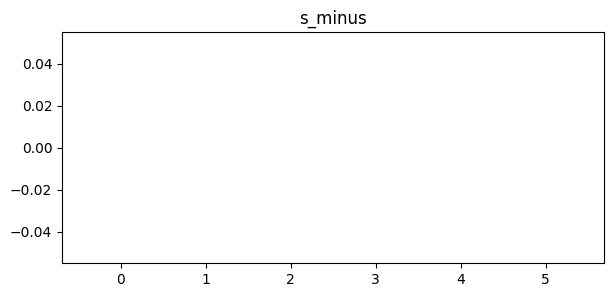

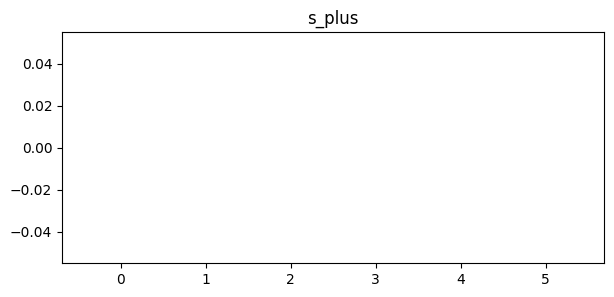

PostgreSQL-demo complete


In [8]:
###############################################################
# 6) Релаксирующая модель (если alpha недостижим)
###############################################################
if sol is None:
    print("Нет Feasible even alpha=0 → применим slack-модель...")

n = 3 * h
c = np.zeros(n)
c[h : 2 * h] = 1
c[2 * h :] = 1  # минимизация суммарного slack

A_eqnp = np.zeros((h, n))
A_eqnp[:, :h] = IminusA
A_eqnp[:, h : 2 * h] = np.eye(h)
A_eqnp[:, 2 * h :] = -np.eye(h)

res = linprog(c, A_eq=A_eqnp, b_eq=Y, bounds=[(0, None)] * n, method="highs")
if res.success:
    X_rel = res.x[:h]
    dfR = prod.copy()
    dfR["x_relaxed"] = X_rel
    dfR["s_minus"] = res.x[h : 2 * h]
    dfR["s_plus"] = res.x[2 * h :]
    display_dataframe_to_user("Relaxed solution", dfR)

    plt.figure(figsize=(7, 3))
    plt.bar(np.arange(h), dfR.s_minus)
    plt.title("s_minus")
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.bar(np.arange(h), dfR.s_plus)
    plt.title("s_plus")
    plt.show()

cur.close()
conn.close()
print("PostgreSQL-demo complete")